# Simulation 
Here we test to see that our code works by injecting a noise at  with band-limited noise and see if we can recover the signal.

In [18]:
import numpy as np 
from matplotlib import pyplot as plt

In [19]:
import numpy as np

def knee_psd_timeseries(n, fs, f_knee=5.0, beta=1.0, rms=1.0, seed=None):
    """
    Real-valued time series with PSD:
      - flat (white) above f_knee
      - ~ 1/f^beta below f_knee
    beta=1 is classic 1/f; beta=2 is random-walk-ish.

    rms sets the final time-series RMS (after mean removal).
    """
    rng = np.random.default_rng(seed)
    freqs = np.fft.rfftfreq(n, d=1/fs)

    # complex white spectrum
    spec = rng.normal(size=freqs.size) + 1j * rng.normal(size=freqs.size)

    # amplitude shaping for desired PSD
    # PSD ~ |spec|^2 * shape^2  => choose shape ~ f^{-beta/2} below knee
    shape = np.ones_like(freqs)
    m = (freqs > 0) & (freqs < f_knee)
    shape[m] = (f_knee / freqs[m]) ** (beta / 2)

    # DC set to 0 (avoid huge low-f blow-up)
    shape[freqs == 0] = 0.0

    spec *= shape

    x = np.fft.irfft(spec, n=n)
    x -= np.mean(x)
    x *= (rms / (np.std(x) + 1e-12))
    return x

In [20]:
def variance_vs_frequency_series(x, coadds_list, frame_dt_s, ddof=1):
    """
    For each coadds, average x into blocks and compute Var(block_means).
    """
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var": []}

    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 2*n:
            continue
        xb = x[:Ntrim].reshape(-1, n).mean(axis=1)   # mean keeps units consistent
        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var"].append(np.var(xb, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}

In [21]:
def variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, ddof=1):
    """
    For each coadds, compute block means then take successive differences and compute Var(diffs).

    
    """
    # Initialize output dictionary
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var_diff": []}

    # Loop over each coadds value
    for n in coadds_list:
        # Trim x to a multiple of n
        Ntrim = (len(x) // n) * n
        if Ntrim < 3*n:   # need at least 3 blocks to get >=2 diffs
            continue
        # Groups n consecutive frames and computes their mean
        xb = x[:Ntrim].reshape(-1, n).mean(axis=1)

        # Computes successive differences (i.e. A - B subtraction)
        d = np.diff(xb)

        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var_diff"].append(np.var(d, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [22]:

# --- your function (unchanged) ---
def variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, ddof=1):
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var_diff": []}
    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 3*n:
            continue
        xb = x[:Ntrim].reshape(-1, n).mean(axis=1)
        d = np.diff(xb)
        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var_diff"].append(np.var(d, ddof=ddof))
    return {k: np.array(v) for k, v in out.items()}

# --- injection ---
def inject_sinusoid(nframes, frame_dt_s, A=1.0, f0=1.0, white_rms=0.0, offset=0.0, seed=0):
    t = np.arange(nframes) * frame_dt_s
    s = A * np.sin(2*np.pi*f0*t)
    rng = np.random.default_rng(seed)
    w = rng.normal(scale=white_rms, size=nframes)
    return offset + s + w

# --- analytic prediction for the sinusoid through (block-mean + diff) ---
def H_avg_sq(f, dt, n):
    x = np.pi * f * dt
    num = np.sin(n*x)
    den = n*np.sin(x)
    # limit as f->0 is 1
    if np.abs(den) < 1e-20:
        return 1.0
    return (num/den)**2

def H_diff_sq(f, dt, n):
    return 4.0 * np.sin(np.pi * f * (n*dt))**2

def predicted_var_for_sinusoid(A, f0, dt, n):
    # sinusoid has variance A^2/2; filtering scales power by |H|^2
    return (A**2 / 2.0) * H_avg_sq(f0, dt, n) * H_diff_sq(f0, dt, n)



In [23]:
nframes = 1600 
frame_dt_s = 0.011
cadds_list = np.arange(5, 251)

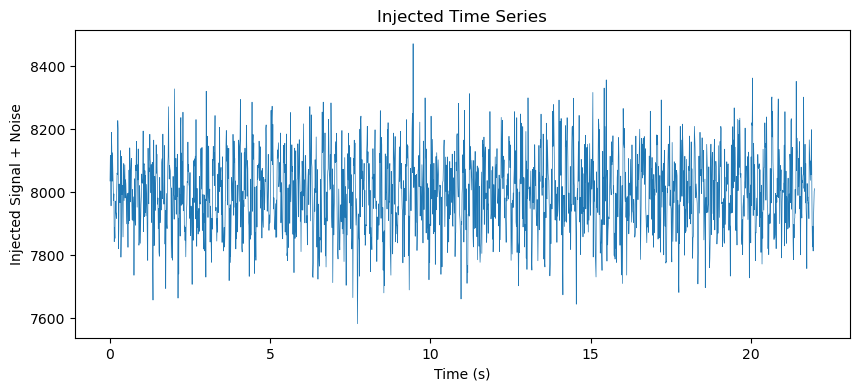

In [77]:
# --- run the test ---
frame_dt_s = 0.011        # <-- set to your frame time
fs = 1.0 / frame_dt_s
nframes = 2000           # long enough to be stable at low f
coadds_list = np.unique(np.round(np.logspace(0, 2.6, 50)).astype(int))  # 1..1000-ish

A = 100.0                   # injected sinusoid amplitude (in same units as x)
f0 = 5              # injected frequency (Hz) - pick below your knee
white_rms = 100.0           # optional noise floor

x = inject_sinusoid(nframes, frame_dt_s, A=A, f0=f0, white_rms=white_rms, offset=8000.0, seed=1)
# plot the injected time series
plt.figure(figsize=(10, 4))
plt.plot(np.arange(nframes) * frame_dt_s, x, lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Injected Signal + Noise')
plt.title('Injected Time Series')
plt.show()


In [78]:
out = variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s)

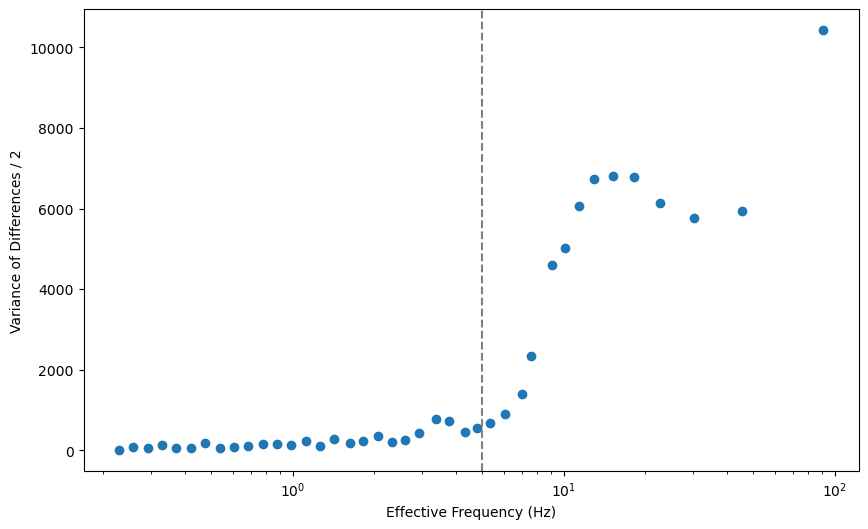

In [79]:
# plot the results 
plt.figure(figsize=(10, 6))
plt.plot(out['f_eff_hz'], out['var_diff']/2, 'o', label='Measured Var(diff)')
plt.xscale('log')
plt.xlabel('Effective Frequency (Hz)')
plt.ylabel('Variance of Differences / 2')

# overplot analytic prediction 
plt.axvline(f0, color='gray', ls='--', label='Injected Frequency')


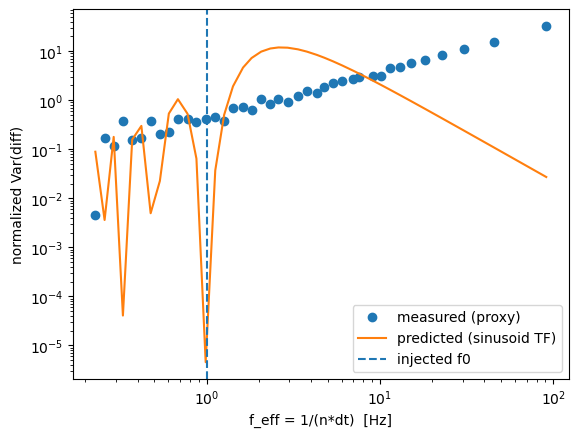

In [58]:
# prediction (up to finite-sample bias; shape is what matters)
v_pred = np.array([predicted_var_for_sinusoid(A, f0, frame_dt_s, n) for n in out["coadds"]])

# normalize both so you compare shapes cleanly
v_meas = out["var_diff"] / np.median(out["var_diff"])
v_pred = v_pred / np.median(v_pred)

plt.figure()
plt.loglog(out["f_eff_hz"], v_meas, "o", label="measured (proxy)")
plt.loglog(out["f_eff_hz"], v_pred, "-", label="predicted (sinusoid TF)")
plt.axvline(f0, linestyle="--", label="injected f0")
#plt.gca().invert_xaxis()  # optional: often nice since n increases to the right otherwise
plt.xlabel("f_eff = 1/(n*dt)  [Hz]")
plt.ylabel("normalized Var(diff)")
plt.legend()
plt.show()